In [1]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In this code we import the data from the mit bih data, and then we plot the graph for the first 10 seconds of the record number 100

Sampling frequency:  360
Signal Shape:  (650000, 2)


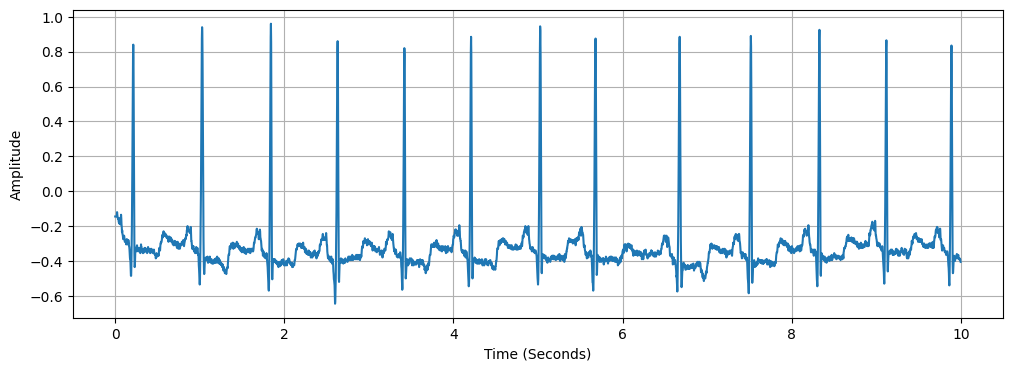

In [2]:
record=wfdb.rdrecord('100', pn_dir='mitdb')
signal=record.p_signal
fs=record.fs

print("Sampling frequency: ",fs)
print("Signal Shape: ",signal.shape)

ecg_signal=signal[:, 0]

time=np.arange(len(ecg_signal))/fs

plt.figure(figsize=(12,4))
plt.plot(time[:10*fs], ecg_signal[:10*fs])
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

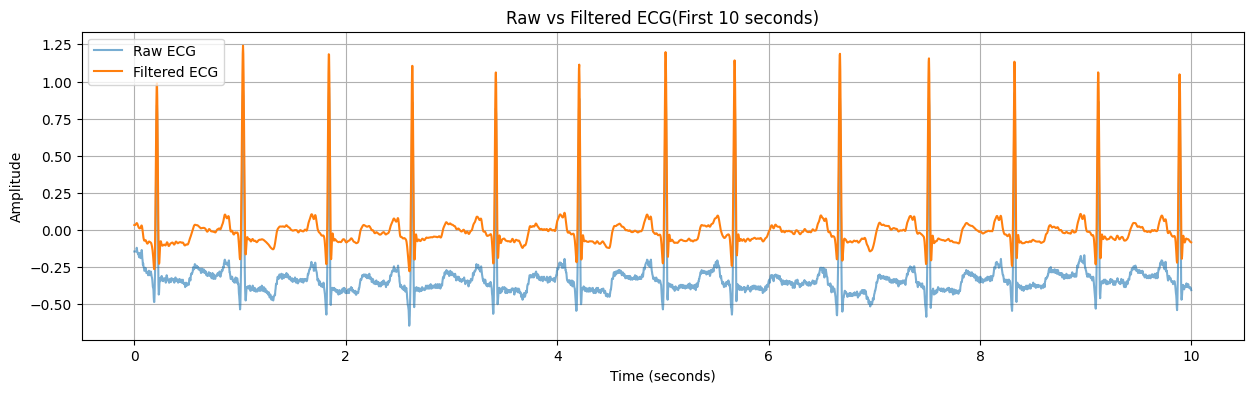

In [3]:
lowcut=0.5
highcut=40.0
order=4

nyquist=0.5*fs 
low=lowcut/nyquist
high=highcut/nyquist

b, a=butter(order,[low, high], btype='band')
filtered_ecg = filtfilt(b, a, ecg_signal)

plt.figure(figsize=(15,4))
plt.plot(time[:10*fs], ecg_signal[:10*fs], label='Raw ECG', alpha=0.6)
plt.plot(time[:10*fs], filtered_ecg[:10*fs], label='Filtered ECG')
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Raw vs Filtered ECG(First 10 seconds)")
plt.legend()
plt.grid(True)
plt.show()

In this graph, we plotted the raw ecg and the filtered ecg, in the filtered ecg we use filtfilt which forward backwrad filtering, which removes noise twice without shifting the phase of the signal 

Nyquist frequency=half of the sampling frequency

In [4]:
from scipy.signal import find_peaks
peaks, properties = find_peaks(
    filtered_ecg,
    distance=int(0.6 * fs),
    height=0.3 * np.max(filtered_ecg)
)

r_peak_time=peaks/fs

rr_intervals=np.diff(r_peak_time)

print("First 10 RR intervals (seconds)")
print(np.round(rr_intervals[:10], 3))
print("\n------------------------\n")
print("R-peak time(seconds)")
for t in r_peak_time[:10]:
    print(round(t,3))

First 10 RR intervals (seconds)
[0.814 0.811 0.792 0.789 0.789 0.817 0.653 0.997 0.842 0.808]

------------------------

R-peak time(seconds)
0.214
1.028
1.839
2.631
3.419
4.208
5.025
5.678
6.675
7.517


In this we find exact time of R peak and the RR interval of first 10 seconds 

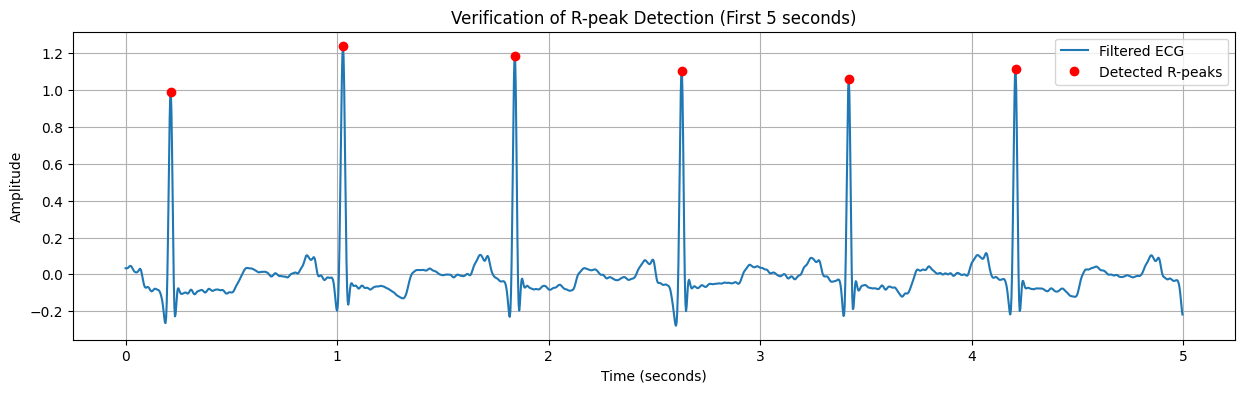

In [5]:
# Limit to first 5 seconds
limit = int(5 * fs)

# Select only peaks within first 5 seconds
peaks_5s = peaks[peaks < limit]

plt.figure(figsize=(15,4))
plt.plot(time[:limit], filtered_ecg[:limit], label="Filtered ECG")
plt.plot(time[peaks_5s], filtered_ecg[peaks_5s], 'ro', label="Detected R-peaks")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Verification of R-peak Detection (First 5 seconds)")
plt.legend()
plt.grid(True)
plt.show()


[]

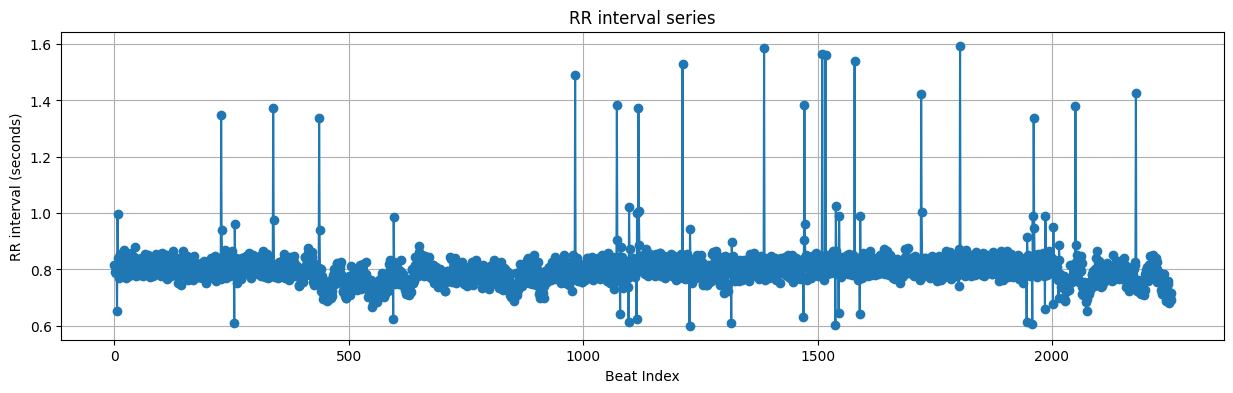

In [6]:
plt.figure(figsize=(15, 4))
plt.plot(rr_intervals, marker='o')
plt.xlabel("Beat Index")
plt.ylabel("RR interval (seconds)")
plt.title("RR interval series")
plt.grid(True)
plt.plot()

RR Interval Analysis
The RR interval series shows a stable rhythm with most intervals between 0.7 and 0.9 seconds, indicating a normal heart rate.
Occasional larger intervals are attributed to detection variability and were handled using physiologically plausible bounds before feature extraction.

In [7]:
# Remove physiologically implausible RR intervals
rr_intervals_clean = rr_intervals[
    (rr_intervals > 0.4) & (rr_intervals < 1.5)
]

print("RR count before cleaning:", len(rr_intervals))
print("RR count after cleaning:", len(rr_intervals_clean))


RR count before cleaning: 2255
RR count after cleaning: 2249


In [8]:
heart_rate=60/rr_intervals_clean

features={
    "mean_RR":np.mean(rr_intervals_clean),
    "std_RR":np.std(rr_intervals_clean),
    "min_RR":np.min(rr_intervals_clean),
    "max_RR":np.max(rr_intervals_clean),
    "mean_HR":np.mean(heart_rate),
    "std_HR":np.std(heart_rate)
}

for k, v in features.items():
    print(f"{k}: {round(v, 3)}")

mean_RR: 0.799
std_RR: 0.059
min_RR: 0.6
max_RR: 1.489
mean_HR: 75.47
std_HR: 4.707


In [9]:
df=pd.DataFrame([features])
df

,mean_RR,std_RR,min_RR,max_RR,mean_HR,std_HR
0,0.798551,0.059192,0.6,1.488889,75.470104,4.70658


In [10]:
def extract_features(record_id):
    record=wfdb.rdrecord(record_id, pn_dir='mitdb')
    signal=record.p_signal
    fs=record.fs

    ecg_signal=signal[:, 0]
    
    nyquist=0.5*fs
    low=0.5/nyquist
    high=40/nyquist
    b, a= butter(4, [low, high], btype='band')
    filtered_ecg=filtfilt(b, a, ecg_signal)

    max_val= np.max(filtered_ecg)
    peaks, _ = find_peaks(
        filtered_ecg, 
        distance=int(0.6*fs),
        height=0.3*max_val
    )

    r_peak_time=peaks/fs
    rr_intervals=np.diff(r_peak_time)

    rr_intervals_clean=rr_intervals[
        (rr_intervals>0.4)&(rr_intervals<1.5)
    ]

    if len(rr_intervals_clean)==0:
        return None
    
    heart_rate=60/rr_intervals_clean

    ann=wfdb.rdann(record_id, 'atr', pn_dir='mitdb')
    abnormal_beats={'V', 'A', 'F', 'L', 'R', 'E'}
    label= 1 if any(sym in abnormal_beats for sym in ann.symbol) else 0

    features={
        "record_id":record_id,
        "mean_RR":np.mean(rr_intervals_clean),
        "std_RR":np.std(rr_intervals_clean),
        "mean_HR":np.mean(heart_rate),
        "std_HR":np.std(heart_rate), 
        "label":label
    }
    return features
    

In [11]:
def get_record_label_symbol(record_id):
    ann=wfdb.rdann(record_id, 'atr', pn_dir='mitdb')
    symbols=ann.symbol

    for sym in ['V','A','L','R','F']:
        if sym in symbols:
            return sym
    return 'N'

In [12]:
records = [
    '100','101','102','103','104','105','106',
    '107','108','109','111','112','113','114',
    '115','116','117','118','119','121'
]

data=[]

for rid in records:
    try:
        feats=extract_features(rid)
        if feats is not None:
            data.append(feats)
        print(f"{rid} done")
    except Exception as e:
        print(f"{rid} failed:", e)

df=pd.DataFrame(data)
df
df['label_symbol'] = df['record_id'].apply(get_record_label_symbol)

symbol_meaning = {
    'N': 'Normal',
    'V': 'Ventricular ectopic beat (PVC)',
    'A': 'Atrial premature beat',
    'L': 'Left bundle branch block',
    'R': 'Right bundle branch block',
    'F': 'Fusion beat'
}

df['label_name'] = df['label_symbol'].map(symbol_meaning)

symbol_to_num = {
    'N': 0,
    'V': 1,
    'A': 2,
    'L': 3,
    'R': 4,
    'F': 5
}

df['label_num'] = df['label_symbol'].map(symbol_to_num)

df


100 done
101 done
102 done
103 done
104 done
105 done
106 done
107 done
108 done
109 done
111 done
112 done
113 done
114 done
115 done
116 done
117 done
118 done
119 done
121 done


,record_id,mean_RR,std_RR,mean_HR,std_HR,label,label_symbol,label_name,label_num
0,100,0.798551,0.059192,75.470104,4.706580,1,V,Ventricular ectopic beat (PVC),1
1,101,0.968020,0.067395,62.304046,4.651768,1,A,Atrial premature beat,2
2,102,0.826761,0.032775,72.670245,2.539378,1,V,Ventricular ectopic beat (PVC),1
3,103,0.866701,0.047262,69.439762,3.919194,1,A,Atrial premature beat,2
4,104,0.811241,0.041090,74.133140,3.485289,1,V,Ventricular ectopic beat (PVC),1
5,105,0.726008,0.106967,83.835466,8.301026,1,V,Ventricular ectopic beat (PVC),1
6,106,0.987771,0.156750,62.178194,9.267172,1,V,Ventricular ectopic beat (PVC),1
7,107,0.860663,0.083744,70.160800,4.763865,1,V,Ventricular ectopic beat (PVC),1
8,108,1.065223,0.090139,56.736781,5.005797,1,V,Ventricular ectopic beat (PVC),1
9,109,0.724271,0.088732,83.565398,6.157279,1,V,Ventricular ectopic beat (PVC),1


In [13]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   record_id     20 non-null     object 
 1   mean_RR       20 non-null     float64
 2   std_RR        20 non-null     float64
 3   mean_HR       20 non-null     float64
 4   std_HR        20 non-null     float64
 5   label         20 non-null     int64  
 6   label_symbol  20 non-null     object 
 7   label_name    20 non-null     object 
 8   label_num     20 non-null     int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 1.5+ KB


,mean_RR,std_RR,mean_HR,std_HR,label,label_num
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,0.894118,0.086517,69.034850,5.747225,0.900000,1.100000
std,0.128314,0.046945,9.472176,2.397555,0.307794,0.552506
min,0.711425,0.023844,51.127660,2.539378,0.000000,0.000000
25%,0.805368,0.058046,62.272583,4.323701,1.000000,1.000000
50%,0.863682,0.085442,69.800281,5.486476,1.000000,1.000000
75%,0.974689,0.099018,75.373170,6.679233,1.000000,1.000000
max,1.176435,0.233405,84.423890,11.604523,1.000000,2.000000


In [14]:
df['label_symbol'].value_counts()

label_symbol
V    14
A     4
N     2
Name: count, dtype: int64

In [15]:
X=df[['mean_RR', 'std_RR', 'mean_HR', 'std_HR']]
y=df['label_num']

In [16]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

model=RandomForestClassifier(
    n_estimators=200, 
    class_weight='balanced', 
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred= model.predict(X_test)

print(classification_report(
    y_test, 
    y_pred,
    target_names=['N', 'V', 'A'],
    zero_division=0
))

              precision    recall  f1-score   support

           N       0.00      0.00      0.00         1
           V       0.80      1.00      0.89         4
           A       1.00      1.00      1.00         1

    accuracy                           0.83         6
   macro avg       0.60      0.67      0.63         6
weighted avg       0.70      0.83      0.76         6



In [20]:
importances = model.feature_importances_

for name, val in zip(X.columns, importances):
    print(f"{name}: {val:.3f}")

mean_RR: 0.198
std_RR: 0.309
mean_HR: 0.213
std_HR: 0.279
